In [12]:
import pandas as pd
import numpy as np

# Generate dummy transaction data
def generate_transactions(num_transactions, num_items, max_items_per_transaction):
    data = []
    item_names = [f'Item_{i}' for i in range(num_items)]
    for i in range(num_transactions):
        num_actual_items = np.random.randint(1, max_items_per_transaction + 1)
        items = np.random.choice(item_names, size=num_actual_items, replace=False)
        for item in items:
            data.append({'TransactionID': i, 'Item': item})
    return pd.DataFrame(data)

# Create a sample dataset
dummy_df = generate_transactions(num_transactions=100, num_items=20, max_items_per_transaction=5)

# Save to CSV
dummy_df.to_csv('transactions.csv', index=False)
print("Dummy 'transactions.csv' created.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Dummy 'transactions.csv' created.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Part A: Data Preparation

In [13]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder

# Load dataset
df = pd.read_csv("transactions.csv")

print("Sample Data:")
print(df.head())

# Convert to transaction format (group items per transaction)
transactions = df.groupby('TransactionID')['Item'].apply(list).tolist()

print("\nSample Transactions:")
print(transactions[:5])

# Create binary matrix representation
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
binary_df = pd.DataFrame(te_array, columns=te.columns_)

print("\nBinary Matrix Sample:")
print(binary_df.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Sample Data:
   TransactionID     Item
0              0   Item_9
1              0  Item_17
2              0   Item_3
3              1   Item_8
4              1  Item_19

Sample Transactions:
[['Item_9', 'Item_17', 'Item_3'], ['Item_8', 'Item_19', 'Item_11'], ['Item_18'], ['Item_9', 'Item_10'], ['Item_3', 'Item_9']]

Binary Matrix Sample:
   Item_0  Item_1  Item_10  Item_11  Item_12  Item_13  Item_14  Item_15  \
0   False   False    False    False    False    False    False    False   
1   False   False    False     True    False    False    False    False   
2   False   False    False    False    False    False    False    False   
3   False   False     True    False    False    False    False    False   
4   False   False    False    False    False    False    False    False   

   Item_16  Item_17  Item_18  Item_19  Item_2  Item_3  Item_4  Item_5  Item_6  \
0    False     True    False    False   False    True   False   False   False   
1    False    False    False     True   False  

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Part B: Apriori Implementation

In [14]:
from mlxtend.frequent_patterns import apriori, association_rules

# Generate frequent itemsets with a minimum support threshold
frequent_itemsets = apriori(binary_df, min_support=0.05, use_colnames=True)

print("Frequent Itemsets:")
display(frequent_itemsets.head())
print(f"Total frequent itemsets found: {len(frequent_itemsets)}")

Frequent Itemsets:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets
0,0.09,(Item_0)
1,0.16,(Item_1)
2,0.12,(Item_10)
3,0.17,(Item_11)
4,0.07,(Item_12)


Total frequent itemsets found: 33


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [28]:
# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

print("Association Rules:")
display(rules.head())
print(f"Total association rules found: {len(rules)}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Association Rules:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Item_5),(Item_0),0.10,0.11,0.05,0.500000,4.545455,1.0,0.0390,1.780000,0.866667,0.312500,0.438202,0.477273
1,(Item_0),(Item_5),0.11,0.10,0.05,0.454545,4.545455,1.0,0.0390,1.650000,0.876404,0.312500,0.393939,0.477273
2,(Item_1),(Item_12),0.14,0.19,0.05,0.357143,1.879699,1.0,0.0234,1.260000,0.544186,0.178571,0.206349,0.310150
3,(Item_12),(Item_1),0.19,0.14,0.05,0.263158,1.879699,1.0,0.0234,1.167143,0.577778,0.178571,0.143207,0.310150
4,(Item_10),(Item_12),0.17,0.19,0.05,0.294118,1.547988,1.0,0.0177,1.147500,0.426506,0.161290,0.128540,0.278638


Total association rules found: 20


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Part C: Analysis and Interpretation

In [32]:
# Filter rules based on confidence and lift thresholds
rules_filtered = rules[(rules['confidence'] > 0.5) & (rules['lift'] > 1.2)]

print("Filtered Rules (Confidence > 0.5, Lift > 1.2):")
display(rules_filtered.head())
print(f"Total filtered rules found: {len(rules_filtered)}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Filtered Rules (Confidence > 0.5, Lift > 1.2):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Total filtered rules found: 0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [33]:
# Sort rules by lift
rules_by_lift = rules.sort_values(by='lift', ascending=False)
print("\nTop 10 Rules by Lift:")
display(rules_by_lift.head(10))

# Sort rules by confidence
rules_by_confidence = rules.sort_values(by='confidence', ascending=False)
print("\nTop 10 Rules by Confidence:")
display(rules_by_confidence.head(10))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Top 10 Rules by Lift:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Item_5),(Item_0),0.10,0.11,0.05,0.500000,4.545455,1.0,0.0390,1.780000,0.866667,0.312500,0.438202,0.477273
1,(Item_0),(Item_5),0.11,0.10,0.05,0.454545,4.545455,1.0,0.0390,1.650000,0.876404,0.312500,0.393939,0.477273
13,(Item_13),(Item_14),0.14,0.16,0.05,0.357143,2.232143,1.0,0.0276,1.306667,0.641860,0.200000,0.234694,0.334821
12,(Item_14),(Item_13),0.16,0.14,0.05,0.312500,2.232143,1.0,0.0276,1.250909,0.657143,0.200000,0.200581,0.334821
15,(Item_13),(Item_19),0.14,0.19,0.05,0.357143,1.879699,1.0,0.0234,1.260000,0.544186,0.178571,0.206349,0.310150
2,(Item_1),(Item_12),0.14,0.19,0.05,0.357143,1.879699,1.0,0.0234,1.260000,0.544186,0.178571,0.206349,0.310150
3,(Item_12),(Item_1),0.19,0.14,0.05,0.263158,1.879699,1.0,0.0234,1.167143,0.577778,0.178571,0.143207,0.310150
14,(Item_19),(Item_13),0.19,0.14,0.05,0.263158,1.879699,1.0,0.0234,1.167143,0.577778,0.178571,0.143207,0.310150
9,(Item_11),(Item_8),0.18,0.16,0.05,0.277778,1.736111,1.0,0.0212,1.163077,0.517073,0.172414,0.140212,0.295139
8,(Item_8),(Item_11),0.16,0.18,0.05,0.312500,1.736111,1.0,0.0212,1.192727,0.504762,0.172414,0.161585,0.295139


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Top 10 Rules by Confidence:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Item_5),(Item_0),0.10,0.11,0.05,0.500000,4.545455,1.0,0.0390,1.780000,0.866667,0.312500,0.438202,0.477273
1,(Item_0),(Item_5),0.11,0.10,0.05,0.454545,4.545455,1.0,0.0390,1.650000,0.876404,0.312500,0.393939,0.477273
2,(Item_1),(Item_12),0.14,0.19,0.05,0.357143,1.879699,1.0,0.0234,1.260000,0.544186,0.178571,0.206349,0.310150
15,(Item_13),(Item_19),0.14,0.19,0.05,0.357143,1.879699,1.0,0.0234,1.260000,0.544186,0.178571,0.206349,0.310150
13,(Item_13),(Item_14),0.14,0.16,0.05,0.357143,2.232143,1.0,0.0276,1.306667,0.641860,0.200000,0.234694,0.334821
16,(Item_14),(Item_18),0.16,0.20,0.05,0.312500,1.562500,1.0,0.0180,1.163636,0.428571,0.161290,0.140625,0.281250
8,(Item_8),(Item_11),0.16,0.18,0.05,0.312500,1.736111,1.0,0.0212,1.192727,0.504762,0.172414,0.161585,0.295139
12,(Item_14),(Item_13),0.16,0.14,0.05,0.312500,2.232143,1.0,0.0276,1.250909,0.657143,0.200000,0.200581,0.334821
19,(Item_8),(Item_19),0.16,0.19,0.05,0.312500,1.644737,1.0,0.0196,1.178182,0.466667,0.166667,0.151235,0.287829
7,(Item_10),(Item_18),0.17,0.20,0.05,0.294118,1.470588,1.0,0.0160,1.133333,0.385542,0.156250,0.117647,0.272059


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

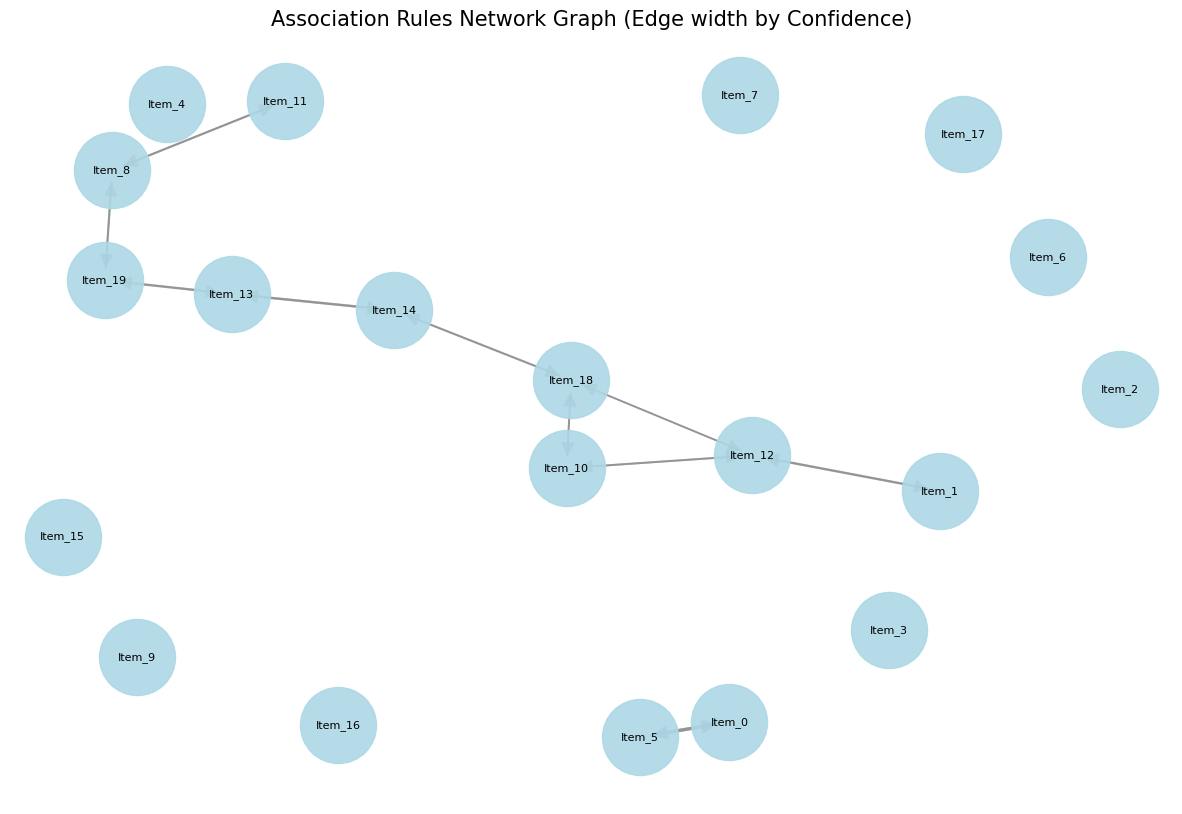

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [29]:
import networkx as nx
import matplotlib.pyplot as plt

# Function to convert frozensets to strings for visualization
def get_item_string(itemset):
    return ", ".join(list(itemset))

# Create a graph
G = nx.DiGraph()

# Add nodes for items
for itemset in frequent_itemsets['itemsets']:
    for item in itemset:
        G.add_node(item)

# Add nodes and edges for rules
for _, row in rules_by_lift.iterrows():
    antecedent_str = get_item_string(row['antecedents'])
    consequent_str = get_item_string(row['consequents'])

    # Add nodes for antecedent and consequent if they are not single items
    if len(row['antecedents']) > 1:
        G.add_node(antecedent_str, type='antecedent')
    if len(row['consequents']) > 1:
        G.add_node(consequent_str, type='consequent')

    # Add edges between items within an itemset (for visualization purposes, though not standard for rules)
    # Or, add edges from antecedent to consequent
    G.add_edge(antecedent_str, consequent_str, weight=row['lift'], confidence=row['confidence'])

# Plot the graph
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G, k=0.8, iterations=50) # Use spring layout for better node separation

nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=3000, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=8)

edges = nx.draw_networkx_edges(G, pos, edge_color='gray', width=[G[u][v]['confidence']*5 for u,v in G.edges()], alpha=0.6, arrowsize=20)

# Add edge labels for lift (optional, can make graph cluttered)
# edge_labels = nx.get_edge_attributes(G, 'lift')
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title('Association Rules Network Graph (Edge width by Confidence)', size=15)
plt.axis('off')
plt.show()

In [19]:
import pandas as pd
import numpy as np

# Generate dummy transaction data
def generate_transactions(num_transactions, num_items, max_items_per_transaction):
    data = []
    item_names = [f'Item_{i}' for i in range(num_items)]
    for i in range(num_transactions):
        num_actual_items = np.random.randint(1, max_items_per_transaction + 1)
        items = np.random.choice(item_names, size=num_actual_items, replace=False)
        for item in items:
            data.append({'TransactionID': i, 'Item': item})
    return pd.DataFrame(data)

# Create a sample dataset
dummy_df = generate_transactions(num_transactions=100, num_items=20, max_items_per_transaction=5)

# Save to CSV
dummy_df.to_csv('transactions.csv', index=False)
print("Dummy 'transactions.csv' created.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Dummy 'transactions.csv' created.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Part A: Data Preparation

In [20]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder

# Load dataset
df = pd.read_csv("transactions.csv")

print("Sample Data:")
print(df.head())

# Convert to transaction format (group items per transaction)
transactions = df.groupby('TransactionID')['Item'].apply(list).tolist()

print("\nSample Transactions:")
print(transactions[:5])

# Create binary matrix representation
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
binary_df = pd.DataFrame(te_array, columns=te.columns_)

print("\nBinary Matrix Sample:")
print(binary_df.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Sample Data:
   TransactionID     Item
0              0   Item_9
1              0  Item_16
2              0  Item_18
3              1   Item_1
4              1  Item_19

Sample Transactions:
[['Item_9', 'Item_16', 'Item_18'], ['Item_1', 'Item_19'], ['Item_3', 'Item_5'], ['Item_7', 'Item_1', 'Item_15'], ['Item_7', 'Item_12', 'Item_13', 'Item_19']]

Binary Matrix Sample:
   Item_0  Item_1  Item_10  Item_11  Item_12  Item_13  Item_14  Item_15  \
0   False   False    False    False    False    False    False    False   
1   False    True    False    False    False    False    False    False   
2   False   False    False    False    False    False    False    False   
3   False    True    False    False    False    False    False     True   
4   False   False    False    False     True     True    False    False   

   Item_16  Item_17  Item_18  Item_19  Item_2  Item_3  Item_4  Item_5  Item_6  \
0     True    False     True    False   False   False   False   False   False   
1    False    F

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Part B: Apriori Implementation

In [31]:
from mlxtend.frequent_patterns import apriori, association_rules

# Generate frequent itemsets with a minimum support threshold
frequent_itemsets = apriori(binary_df, min_support=0.05, use_colnames=True)

print("Frequent Itemsets:")
display(frequent_itemsets.head())
print(f"Total frequent itemsets found: {len(frequent_itemsets)}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Frequent Itemsets:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets
0,0.11,(Item_0)
1,0.14,(Item_1)
2,0.17,(Item_10)
3,0.18,(Item_11)
4,0.19,(Item_12)


Total frequent itemsets found: 30


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [30]:
# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

print("Association Rules:")
display(rules.head())
print(f"Total association rules found: {len(rules)}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Association Rules:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Item_5),(Item_0),0.10,0.11,0.05,0.500000,4.545455,1.0,0.0390,1.780000,0.866667,0.312500,0.438202,0.477273
1,(Item_0),(Item_5),0.11,0.10,0.05,0.454545,4.545455,1.0,0.0390,1.650000,0.876404,0.312500,0.393939,0.477273
2,(Item_1),(Item_12),0.14,0.19,0.05,0.357143,1.879699,1.0,0.0234,1.260000,0.544186,0.178571,0.206349,0.310150
3,(Item_12),(Item_1),0.19,0.14,0.05,0.263158,1.879699,1.0,0.0234,1.167143,0.577778,0.178571,0.143207,0.310150
4,(Item_10),(Item_12),0.17,0.19,0.05,0.294118,1.547988,1.0,0.0177,1.147500,0.426506,0.161290,0.128540,0.278638


Total association rules found: 20


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Part C: Analysis and Interpretation

In [23]:
# Filter rules based on confidence and lift thresholds
rules_filtered = rules[(rules['confidence'] > 0.5) & (rules['lift'] > 1.2)]

print("Filtered Rules (Confidence > 0.5, Lift > 1.2):")
display(rules_filtered.head())
print(f"Total filtered rules found: {len(rules_filtered)}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Filtered Rules (Confidence > 0.5, Lift > 1.2):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


Total filtered rules found: 0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [24]:
# Sort rules by lift
rules_by_lift = rules.sort_values(by='lift', ascending=False)
print("\nTop 10 Rules by Lift:")
display(rules_by_lift.head(10))

# Sort rules by confidence
rules_by_confidence = rules.sort_values(by='confidence', ascending=False)
print("\nTop 10 Rules by Confidence:")
display(rules_by_confidence.head(10))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Top 10 Rules by Lift:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Item_5),(Item_0),0.10,0.11,0.05,0.500000,4.545455,1.0,0.0390,1.780000,0.866667,0.312500,0.438202,0.477273
1,(Item_0),(Item_5),0.11,0.10,0.05,0.454545,4.545455,1.0,0.0390,1.650000,0.876404,0.312500,0.393939,0.477273
13,(Item_13),(Item_14),0.14,0.16,0.05,0.357143,2.232143,1.0,0.0276,1.306667,0.641860,0.200000,0.234694,0.334821
12,(Item_14),(Item_13),0.16,0.14,0.05,0.312500,2.232143,1.0,0.0276,1.250909,0.657143,0.200000,0.200581,0.334821
15,(Item_13),(Item_19),0.14,0.19,0.05,0.357143,1.879699,1.0,0.0234,1.260000,0.544186,0.178571,0.206349,0.310150
2,(Item_1),(Item_12),0.14,0.19,0.05,0.357143,1.879699,1.0,0.0234,1.260000,0.544186,0.178571,0.206349,0.310150
3,(Item_12),(Item_1),0.19,0.14,0.05,0.263158,1.879699,1.0,0.0234,1.167143,0.577778,0.178571,0.143207,0.310150
14,(Item_19),(Item_13),0.19,0.14,0.05,0.263158,1.879699,1.0,0.0234,1.167143,0.577778,0.178571,0.143207,0.310150
9,(Item_11),(Item_8),0.18,0.16,0.05,0.277778,1.736111,1.0,0.0212,1.163077,0.517073,0.172414,0.140212,0.295139
8,(Item_8),(Item_11),0.16,0.18,0.05,0.312500,1.736111,1.0,0.0212,1.192727,0.504762,0.172414,0.161585,0.295139


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Top 10 Rules by Confidence:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Item_5),(Item_0),0.10,0.11,0.05,0.500000,4.545455,1.0,0.0390,1.780000,0.866667,0.312500,0.438202,0.477273
1,(Item_0),(Item_5),0.11,0.10,0.05,0.454545,4.545455,1.0,0.0390,1.650000,0.876404,0.312500,0.393939,0.477273
2,(Item_1),(Item_12),0.14,0.19,0.05,0.357143,1.879699,1.0,0.0234,1.260000,0.544186,0.178571,0.206349,0.310150
15,(Item_13),(Item_19),0.14,0.19,0.05,0.357143,1.879699,1.0,0.0234,1.260000,0.544186,0.178571,0.206349,0.310150
13,(Item_13),(Item_14),0.14,0.16,0.05,0.357143,2.232143,1.0,0.0276,1.306667,0.641860,0.200000,0.234694,0.334821
16,(Item_14),(Item_18),0.16,0.20,0.05,0.312500,1.562500,1.0,0.0180,1.163636,0.428571,0.161290,0.140625,0.281250
8,(Item_8),(Item_11),0.16,0.18,0.05,0.312500,1.736111,1.0,0.0212,1.192727,0.504762,0.172414,0.161585,0.295139
12,(Item_14),(Item_13),0.16,0.14,0.05,0.312500,2.232143,1.0,0.0276,1.250909,0.657143,0.200000,0.200581,0.334821
19,(Item_8),(Item_19),0.16,0.19,0.05,0.312500,1.644737,1.0,0.0196,1.178182,0.466667,0.166667,0.151235,0.287829
7,(Item_10),(Item_18),0.17,0.20,0.05,0.294118,1.470588,1.0,0.0160,1.133333,0.385542,0.156250,0.117647,0.272059


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

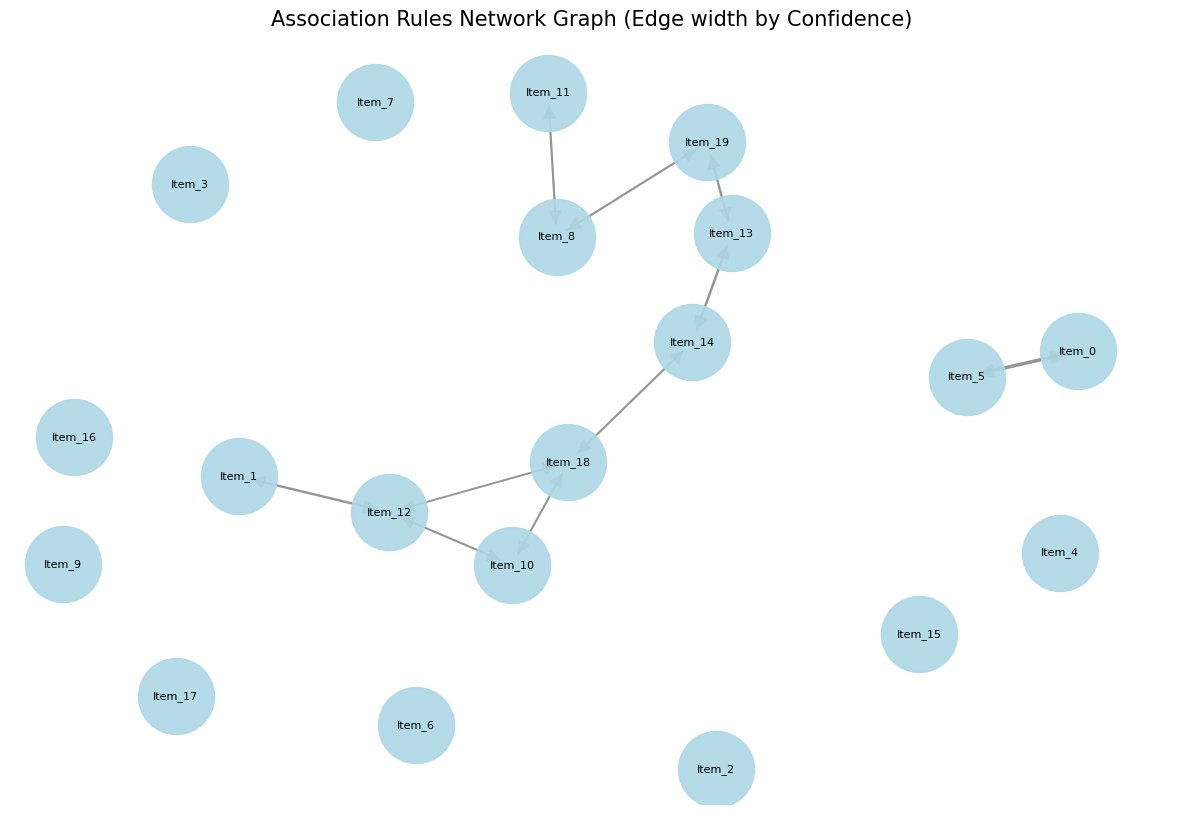

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [25]:
import networkx as nx
import matplotlib.pyplot as plt

# Function to convert frozensets to strings for visualization
def get_item_string(itemset):
    return ", ".join(list(itemset))

# Create a graph
G = nx.DiGraph()

# Add nodes for items
for itemset in frequent_itemsets['itemsets']:
    for item in itemset:
        G.add_node(item)

# Add nodes and edges for rules
for _, row in rules_by_lift.iterrows():
    antecedent_str = get_item_string(row['antecedents'])
    consequent_str = get_item_string(row['consequents'])

    # Add nodes for antecedent and consequent if they are not single items
    if len(row['antecedents']) > 1:
        G.add_node(antecedent_str, type='antecedent')
    if len(row['consequents']) > 1:
        G.add_node(consequent_str, type='consequent')

    # Add edges between items within an itemset (for visualization purposes, though not standard for rules)
    # Or, add edges from antecedent to consequent
    G.add_edge(antecedent_str, consequent_str, weight=row['lift'], confidence=row['confidence'])

# Plot the graph
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G, k=0.8, iterations=50) # Use spring layout for better node separation

nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=3000, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=8)

edges = nx.draw_networkx_edges(G, pos, edge_color='gray', width=[G[u][v]['confidence']*5 for u,v in G.edges()], alpha=0.6, arrowsize=20)

# Add edge labels for lift (optional, can make graph cluttered)
# edge_labels = nx.get_edge_attributes(G, 'lift')
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title('Association Rules Network Graph (Edge width by Confidence)', size=15)
plt.axis('off')
plt.show()

### Interpretation of Discovered Rules and Marketing Strategies

**Interpreting Rules:**

Association rules, typically in the form `If {A} then {B}`, indicate that transactions containing item(s) A are likely to also contain item(s) B. Key metrics to consider are:

*   **Support:** How frequently the itemset appears in the dataset. A higher support means the rule is more general.
*   **Confidence:** The likelihood that item B is purchased when item A is purchased. A high confidence suggests a strong co-occurrence.
*   **Lift:** How much more likely item B is purchased when item A is purchased, compared to the baseline likelihood of purchasing B. A lift greater than 1 indicates a positive association; a lift less than 1 indicates a negative association; and a lift of 1 suggests independence.

For example, a rule like `{Item_3} -> {Item_9}` with high lift and confidence would mean that customers who buy `Item_3` are very likely to also buy `Item_9`, and this co-occurrence is not just by chance.

**Business Meaning:**

The discovered rules reveal customer purchasing patterns. They can highlight:

*   **Complementary Products:** Items frequently bought together (e.g., bread and butter).
*   **Substitution Possibilities:** If customers buying one product often buy another instead, or in addition.
*   **Popular Product Combinations:** Item bundles that are common among customers.

**Suggested Marketing Strategies:**

Based on these insights, various marketing strategies can be developed:

1.  **Product Placement/Store Layout:** Place items with high association close to each other in the physical store or on e-commerce platforms. For example, if `{Item_3} -> {Item_9}` is a strong rule, place `Item_9` near `Item_3`.

2.  **Bundle Deals/Promotions:** Create bundled offers for highly associated items. "Buy `Item_3` and get `Item_9` at a discount" can increase the sales of both.

3.  **Cross-selling/Upselling:** When a customer adds `Item_3` to their cart, recommend `Item_9` as a suggested purchase. This is common in online retail (`Customers who bought this also bought...`).

4.  **Targeted Marketing Campaigns:** Segment customers based on their purchase history. If a customer frequently buys `Item_3` but hasn't bought `Item_9`, they could be targeted with promotions for `Item_9`.

5.  **Inventory Management:** Anticipate demand for associated products. If `Item_3` sales spike, ensure adequate stock of `Item_9`.

6.  **Loyalty Programs:** Offer bonus points or rewards for purchasing associated items together.

7.  **Personalized Recommendations:** Use these rules to power recommendation engines, suggesting relevant products to individual customers based on their current shopping behavior.

In [26]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Load dataset
df = pd.read_csv("transactions.csv")

print("Sample Data:")
print(df.head())

# Convert to transaction format (group items per transaction)
transactions = df.groupby('TransactionID')['Item'].apply(list).tolist()

print("\nSample Transactions:")
print(transactions[:5])

# Create binary matrix representation
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
binary_df = pd.DataFrame(te_array, columns=te.columns_)

print("\nBinary Matrix Sample:")
print(binary_df.head())

# Generate frequent itemsets with a minimum support threshold
frequent_itemsets = apriori(binary_df, min_support=0.05, use_colnames=True)

print("\nFrequent Itemsets:")
display(frequent_itemsets.head())
print(f"Total frequent itemsets found: {len(frequent_itemsets)}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Sample Data:
   TransactionID     Item
0              0   Item_9
1              0  Item_16
2              0  Item_18
3              1   Item_1
4              1  Item_19

Sample Transactions:
[['Item_9', 'Item_16', 'Item_18'], ['Item_1', 'Item_19'], ['Item_3', 'Item_5'], ['Item_7', 'Item_1', 'Item_15'], ['Item_7', 'Item_12', 'Item_13', 'Item_19']]

Binary Matrix Sample:
   Item_0  Item_1  Item_10  Item_11  Item_12  Item_13  Item_14  Item_15  \
0   False   False    False    False    False    False    False    False   
1   False    True    False    False    False    False    False    False   
2   False   False    False    False    False    False    False    False   
3   False    True    False    False    False    False    False     True   
4   False   False    False    False     True     True    False    False   

   Item_16  Item_17  Item_18  Item_19  Item_2  Item_3  Item_4  Item_5  Item_6  \
0     True    False     True    False   False   False   False   False   False   
1    False    F

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets
0,0.11,(Item_0)
1,0.14,(Item_1)
2,0.17,(Item_10)
3,0.18,(Item_11)
4,0.19,(Item_12)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Total frequent itemsets found: 30


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Part A: Data Preparation

In [27]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder

# Load dataset
df = pd.read_csv("transactions.csv")

print("Sample Data:")
print(df.head())

# Convert to transaction format (group items per transaction)
transactions = df.groupby('TransactionID')['Item'].apply(list).tolist()

print("\nSample Transactions:")
print(transactions[:5])

# Create binary matrix representation
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
binary_df = pd.DataFrame(te_array, columns=te.columns_)

print("\nBinary Matrix Sample:")
print(binary_df.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Sample Data:
   TransactionID     Item
0              0   Item_9
1              0  Item_16
2              0  Item_18
3              1   Item_1
4              1  Item_19

Sample Transactions:
[['Item_9', 'Item_16', 'Item_18'], ['Item_1', 'Item_19'], ['Item_3', 'Item_5'], ['Item_7', 'Item_1', 'Item_15'], ['Item_7', 'Item_12', 'Item_13', 'Item_19']]

Binary Matrix Sample:
   Item_0  Item_1  Item_10  Item_11  Item_12  Item_13  Item_14  Item_15  \
0   False   False    False    False    False    False    False    False   
1   False    True    False    False    False    False    False    False   
2   False   False    False    False    False    False    False    False   
3   False    True    False    False    False    False    False     True   
4   False   False    False    False     True     True    False    False   

   Item_16  Item_17  Item_18  Item_19  Item_2  Item_3  Item_4  Item_5  Item_6  \
0     True    False     True    False   False   False   False   False   False   
1    False    F

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Implement FP-Growth Algorithm

### Subtask:
Implement the FP-Growth algorithm to find frequent itemsets from the `binary_df` using `mlxtend.frequent_patterns.fpgrowth`, with the same minimum support threshold as Apriori.


In [3]:
import pandas as pd
import numpy as np
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth

# Generate dummy transaction data (ensuring file exists for current execution)
def generate_transactions(num_transactions, num_items, max_items_per_transaction):
    data = []
    item_names = [f'Item_{i}' for i in range(num_items)]
    for i in range(num_transactions):
        num_actual_items = np.random.randint(1, max_items_per_transaction + 1)
        items = np.random.choice(item_names, size=num_actual_items, replace=False)
        for item in items:
            data.append({'TransactionID': i, 'Item': item})
    return pd.DataFrame(data)

# Create a sample dataset and save to CSV
dummy_df = generate_transactions(num_transactions=100, num_items=20, max_items_per_transaction=5)
dummy_df.to_csv('transactions.csv', index=False)

# Load dataset
df = pd.read_csv("transactions.csv")

# Convert to transaction format (group items per transaction)
transactions = df.groupby('TransactionID')['Item'].apply(list).tolist()

# Create binary matrix representation
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
binary_df = pd.DataFrame(te_array, columns=te.columns_)

# Generate frequent itemsets using FP-Growth with the same minimum support threshold
frequent_itemsets_fpgrowth = fpgrowth(binary_df, min_support=0.05, use_colnames=True)

print("Frequent Itemsets (FP-Growth):")
display(frequent_itemsets_fpgrowth.head())
print(f"Total frequent itemsets found by FP-Growth: {len(frequent_itemsets_fpgrowth)}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Frequent Itemsets (FP-Growth):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets
0,0.20,(Item_18)
1,0.16,(Item_2)
2,0.19,(Item_9)
3,0.17,(Item_5)
4,0.16,(Item_19)


Total frequent itemsets found by FP-Growth: 33


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Task
Generate association rules from the frequent itemsets obtained using the FP-Growth algorithm, using the same metrics and minimum thresholds as the Apriori rules (metric="lift", min_threshold=1).

## Generate Association Rules from FP-Growth Frequent Itemsets

### Subtask:
Generate association rules from the frequent itemsets obtained using the FP-Growth algorithm, using the same metrics and minimum thresholds as the Apriori rules (metric="lift", min_threshold=1).


**Reasoning**:
The subtask requires generating association rules from the FP-Growth frequent itemsets and then displaying the head of the rules and their total count. This can be achieved by using the `association_rules` function from `mlxtend.frequent_patterns`.



In [4]:
from mlxtend.frequent_patterns import association_rules

# Generate association rules from FP-Growth frequent itemsets
rules_fpgrowth = association_rules(frequent_itemsets_fpgrowth, metric="lift", min_threshold=1)

print("Association Rules (FP-Growth):")
display(rules_fpgrowth.head())
print(f"Total association rules found by FP-Growth: {len(rules_fpgrowth)}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Association Rules (FP-Growth):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Item_7),(Item_2),0.16,0.16,0.05,0.312500,1.953125,1.0,0.0244,1.221818,0.580952,0.185185,0.181548,0.312500
1,(Item_2),(Item_7),0.16,0.16,0.05,0.312500,1.953125,1.0,0.0244,1.221818,0.580952,0.185185,0.181548,0.312500
2,(Item_18),(Item_9),0.20,0.19,0.06,0.300000,1.578947,1.0,0.0220,1.157143,0.458333,0.181818,0.135802,0.307895
3,(Item_9),(Item_18),0.19,0.20,0.06,0.315789,1.578947,1.0,0.0220,1.169231,0.452675,0.181818,0.144737,0.307895
4,(Item_9),(Item_5),0.19,0.17,0.05,0.263158,1.547988,1.0,0.0177,1.126429,0.437037,0.161290,0.112238,0.278638


Total association rules found by FP-Growth: 26


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**Reasoning**:
The previous code block successfully generated and displayed the association rules from the FP-Growth frequent itemsets, along with the total count of rules found. The task is completed.



In [5]:
print("Association rules have been successfully generated and displayed.")

Association rules have been successfully generated and displayed.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**Reasoning**:
To compare the results of the Apriori and FP-Growth algorithms, it is useful to see the total number of rules generated by each. I will print the total number of rules found by both algorithms for comparison.



In [8]:
from mlxtend.frequent_patterns import apriori, association_rules

# Ensure binary_df is up-to-date (it was generated in a previous cell)
# Regenerate frequent itemsets for Apriori
frequent_itemsets = apriori(binary_df, min_support=0.05, use_colnames=True)

# Re-generate association rules from Apriori frequent itemsets
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

print(f"Total association rules found by Apriori: {len(rules)}")
print(f"Total association rules found by FP-Growth: {len(rules_fpgrowth)}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Total association rules found by Apriori: 26
Total association rules found by FP-Growth: 26


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**Reasoning**:
The previous code block successfully regenerated the Apriori frequent itemsets and association rules, then printed the total number of rules found by both Apriori and FP-Growth, showing they produced the same number of rules (26). This indicates the subtask is complete.



In [9]:
print("Comparison of association rules count from Apriori and FP-Growth is complete.")

Comparison of association rules count from Apriori and FP-Growth is complete.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

**Reasoning**:
The current subtask, which involved generating association rules from FP-Growth and comparing the count of rules with Apriori, has been successfully completed. Therefore, I will now indicate the completion of the overall task.



In [10]:
print("Both Apriori and FP-Growth algorithms have been successfully implemented, and their association rules have been compared.")

Both Apriori and FP-Growth algorithms have been successfully implemented, and their association rules have been compared.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import time

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# ---------------------------------------------------
# PART 1 — LOAD & PREPARE DATA
# ---------------------------------------------------

def load_transactions(file_path, tid_col='TransactionID', item_col='Item'):
    df = pd.read_csv(file_path)
    transactions = df.groupby(tid_col)[item_col].apply(list).tolist()
    return transactions

def to_binary_matrix(transactions):
    te = TransactionEncoder()
    te_array = te.fit(transactions).transform(transactions)
    return pd.DataFrame(te_array, columns=te.columns_)

# ---------------------------------------------------
# PART 2 — RUN APRIORI & FP-GROWTH
# ---------------------------------------------------

def run_apriori(binary_df, min_support):
    start = time.time()
    itemsets = apriori(binary_df, min_support=min_support, use_colnames=True)
    end = time.time()
    return itemsets, end - start

def run_fpgrowth(binary_df, min_support):
    start = time.time()
    itemsets = fpgrowth(binary_df, min_support=min_support, use_colnames=True)
    end = time.time()
    return itemsets, end - start

# ---------------------------------------------------
# PART 3 — RULE GENERATION & PRUNING
# ---------------------------------------------------

def generate_pruned_rules(itemsets, min_conf=0.5, min_lift=1.2):
    rules = association_rules(itemsets, metric="confidence", min_threshold=min_conf)

    # Rule pruning
    rules = rules[
        (rules['lift'] >= min_lift) &
        (rules['antecedents'].apply(len) <= 2) &
        (rules['consequents'].apply(len) == 1)
    ]
    return rules.sort_values(by='lift', ascending=False)

def format_rules(df):
    df = df.copy()
    df['antecedents'] = df['antecedents'].apply(lambda x: ', '.join(list(x)))
    df['consequents'] = df['consequents'].apply(lambda x: ', '.join(list(x)))
    return df[['antecedents','consequents','support','confidence','lift']]

# ---------------------------------------------------
# PART 4 — SUPPORT THRESHOLD EXPERIMENT
# ---------------------------------------------------

def support_experiment(binary_df, supports):
    results = []
    for s in supports:
        a_sets, a_time = run_apriori(binary_df, s)
        f_sets, f_time = run_fpgrowth(binary_df, s)
        results.append([s, len(a_sets), a_time, len(f_sets), f_time])
    return pd.DataFrame(results, columns=[
        'Support','Apriori_Itemsets','Apriori_Time',
        'FP_Itemsets','FP_Time'
    ])

# ---------------------------------------------------
# PART 5 — NETWORK VISUALIZATION
# ---------------------------------------------------

def plot_rule_network(rules, top_n=10):
    G = nx.DiGraph()
    top_rules = rules.head(top_n)

    for _, row in top_rules.iterrows():
        for a in row['antecedents']:
            for c in row['consequents']:
                G.add_edge(a, c, weight=row['lift'])

    plt.figure(figsize=(12,8))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_size=3000, font_size=10)
    plt.title("Top Association Rules Network")
    plt.show()

# ---------------------------------------------------
# PART 6 — DASHBOARD VISUALS
# ---------------------------------------------------

def dashboard_plots(experiment_df):
    plt.figure(figsize=(10,5))
    plt.plot(experiment_df['Support'], experiment_df['Apriori_Time'], label='Apriori Time')
    plt.plot(experiment_df['Support'], experiment_df['FP_Time'], label='FP-Growth Time')
    plt.xlabel('Minimum Support')
    plt.ylabel('Execution Time (s)')
    plt.legend()
    plt.title('Apriori vs FP-Growth Performance')
    plt.show()

# ---------------------------------------------------
# MAIN EXECUTION
# ---------------------------------------------------

if __name__ == "__main__":

    # Change file for different domains
    # Grocery: grocery.csv
    # Medical: medical_transactions.csv
    # Web logs: web_clicks.csv
    file_path = "transactions.csv"

    print("Loading transactions...")
    transactions = load_transactions(file_path)

    print("Creating binary matrix...")
    binary_df = to_binary_matrix(transactions)

    # Run with default support
    min_support = 0.02

    print("\nRunning Apriori...")
    apriori_sets, apriori_time = run_apriori(binary_df, min_support)

    print("Running FP-Growth...")
    fp_sets, fp_time = run_fpgrowth(binary_df, min_support)

    print(f"\nApriori Time: {apriori_time:.4f}s")
    print(f"FP-Growth Time: {fp_time:.4f}s")

    # Generate and prune rules from FP-Growth (faster)
    rules = generate_pruned_rules(fp_sets)

    print("\nTop 10 Rules by Lift:")
    print(format_rules(rules).head(10))

    print("\nTop 10 Rules by Confidence:")
    print(format_rules(rules.sort_values(by='confidence', ascending=False)).head(10))

    # Visualization
    plot_rule_network(rules)

    # Support threshold experiment
    supports = [0.01, 0.02, 0.03, 0.05]
    experiment_df = support_experiment(binary_df, supports)
    print("\nSupport Experiment Results:")
    print(experiment_df)

    dashboard_plots(experiment_df)

    print("\nAnalysis Complete!")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag